**Exploratory Data Analysis (EDA) и подготовка данных**

**Этапы:**
1. Загрузка данных из .txt файлов
2. Базовая статистика и визуализация временных рядов
3. Очистка данных (удаление выбросов и аномалий)
4. Анализ циклов работы ШГН (спектральный анализ)
5. Корреляционный анализ признаков
6. Нормализация (StandardScaler) — скважины ШГН объединяются и нормализуются вместе
7. Разделение на train/validation/test (80%/10%/10%)

**Вход:**
- data/скважина 133 ЭЦН/*.txt (16 файлов)
- data/скважина 134 ШГН/*.txt (9 файлов)
- data/скважина 135 ШГН/*.txt (6 файлов)

**Выход:**
- data/processed/ecn_train.csv, ecn_val.csv, ecn_test.csv (скважина 133)
- data/processed/shgn_train.csv, shgn_val.csv, shgn_test.csv (скважины 134+135 объединённые)
- data/processed/scaler_ecn.pkl, scaler_shgn.pkl

In [1]:
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import signal
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (15, 6)

## Этап 1: Загрузка данных из .txt файлов

Структура данных:
- Дата, Время, 9 параметров влагомера, Номер отвода (игнорируем)
- Разделитель: табуляция
- Интервал: 10 секунд

In [4]:
COLUMN_NAMES = [
    'date', 'time',
    'us_center', 'us_periph',
    'gas_center', 'gas_periph',
    'temp',
    'water_center', 'water_periph',
    'outlet_num',
    'gas_integral', 'water_integral'
]

FEATURE_COLUMNS = [
    'us_center', 'us_periph',
    'gas_center', 'gas_periph',
    'temp',
    'water_center', 'water_periph',
    'gas_integral', 'water_integral'
]

DATA_ROOT = Path('../data')

WELLS = {
    'ecn': ['скважина 133 ЭЦН'],
    'shgn': ['скважина 134 ШГН', 'скважина 135 ШГН']
}

In [10]:
def load_well_data(well_folder, date_filter=None):
    txt_files = sorted(well_folder.glob("*.txt"))

    if not txt_files:
        print(f"Нет .txt файлов в {well_folder}")
        return pd.DataFrame()

    print(f"Найдено {len(txt_files)} файлов в {well_folder.name}")

    dfs = []
    for file in txt_files:
        try:
            df = pd.read_csv(file, sep="\t", names=COLUMN_NAMES, encoding="utf-8")
            df["timestamp"] = pd.to_datetime(df["date"] + " " + df["time"], format="%Y.%m.%d %H:%M:%S")
            df = df.drop(columns=["date", "time"])
            df["well"] = well_folder.name
            dfs.append(df)
        except Exception as e:
            print(f"Ошибка чтения {file.name}: {e}")

    if not dfs:
        return pd.DataFrame()

    combined = pd.concat(dfs, ignore_index=True)
    combined = combined.sort_values("timestamp").reset_index(drop=True)

    if date_filter:
        mask = combined["timestamp"] >= date_filter
        removed = (~mask).sum()
        combined = combined[mask].reset_index(drop=True)
        print(f"  Фильтр по дате: удалено {removed} записей")

    print(f"  Загружено {len(combined):,} записей")
    print(f"  Период: {combined['timestamp'].min()} - {combined['timestamp'].max()}")

    return combined


In [25]:
df_ecn = load_well_data(DATA_ROOT / "скважина 133 ЭЦН")

Найдено 16 файлов в скважина 133 ЭЦН
  Загружено 51,908 записей
  Период: 2021-11-01 08:59:50 - 2021-12-01 07:54:30


In [26]:
df_shgn_134 = load_well_data(DATA_ROOT / "скважина 134 ШГН", date_filter="2021-01-01")

Найдено 9 файлов в скважина 134 ШГН
  Фильтр по дате: удалено 1 записей
  Загружено 83,486 записей
  Период: 2021-11-01 00:00:00 - 2021-11-30 23:54:20


In [27]:
df_shgn_135 = load_well_data(DATA_ROOT / "скважина 135 ШГН")

Найдено 6 файлов в скважина 135 ШГН
  Загружено 47,631 записей
  Период: 2021-10-19 23:59:30 - 2021-11-30 23:54:20


## EDA: Exploratory Data Analysis

### 1. Базовая статистика

In [14]:
def print_basic_stats(df, name):
    duration = (df["timestamp"].max() - df["timestamp"].min()).days
    interval = df["timestamp"].diff().dt.total_seconds().median()
    missing = df[FEATURE_COLUMNS].isnull().sum()
    duplicates = df[FEATURE_COLUMNS].duplicated().sum()

    print(f"{'=' * 70}")
    print(f"{name}")
    print(f"{'=' * 70}")
    print(f"Записей: {len(df):,} | Период: {duration} дней | Интервал: {interval / 60:.1f} мин")
    print(f"Дубликаты признаков: {duplicates}")
    print("\nПропуски по колонкам:")
    for col, count in missing[missing > 0].items():
        print(f"  {col}: {count}")
    if missing.sum() == 0:
        print("  Нет пропусков")
    print(f"\n{df[FEATURE_COLUMNS].describe().round(2)}\n")


print_basic_stats(df_ecn, "ЭЦН (скважина 133)")
print_basic_stats(df_shgn_134, "ШГН (скважина 134)")
print_basic_stats(df_shgn_135, "ШГН (скважина 135)")

ЭЦН (скважина 133)
Записей: 51,908 | Период: 29 дней | Интервал: 0.2 мин
Дубликаты признаков: 18533

Пропуски по колонкам:
  Нет пропусков

       us_center  us_periph  gas_center  gas_periph      temp  water_center  \
count   51908.00   51908.00    51908.00    51908.00  51908.00      51908.00   
mean     1557.08    1570.09        0.47        0.29     -4.21         57.94   
std       199.22     132.00        0.47        0.45     33.12         44.30   
min         0.00       0.00        0.00        0.00   -656.84          0.00   
25%      1506.60    1507.90        0.00        0.00     -5.05          0.00   
50%      1588.30    1598.70        0.28        0.00     -2.02         78.26   
75%      1641.00    1622.60        1.00        0.98      0.00        100.00   
max      1992.20    1976.20        1.00       18.94      2.02        100.00   

       water_periph  gas_integral  water_integral  
count      51908.00      51908.00        51908.00  
mean          60.55          0.38           

| Параметр                | ЭЦН (133)                   | ШГН (134)                           | ШГН (135)                                                                         |
| :---------------------- | :-------------------------- | :---------------------------------- | :-------------------------------------------------------------------------------- |
| **Тип насоса**          | Электроцентробежный         | Штанговый (качалка)                 | Штанговый (качалка)                                                               |
| **Режим работы**        | Периодический (вкл/выкл)    | Циклический (~7 мин)                | Циклический (~7 мин)                                                              |
| **Записей**             | 51 908                      | 83 486                              | 47 631                                                                            |
| **Период**              | 29 дней                     | 29 дней                             | 41 день                                                                           |
| **Дубликаты**           | 18 533 (36%) — простои      | 8 045 (10%)                         | 1 242 (3%)                                                                        |
| **Скорость звука, м/с** | 1557 / 1570                 | 1584 / 1595                         | 1607 / 1602                                                                       |
| **Газ, %**              | 47 / 29                     | 31 / 20                             | **5 / 3**                                                                         |
| **Вода, %**             | 58 / 61                     | 77 / 78                             | **86 / 85**                                                                       |
| **Температура, °C**     | **-4 ± 33** (от -657 до +2) | **10 ± 0.6**                        | **12 ± 0.6**                                                                      |
| **Разброс US**          | Высокий (±200)              | **Очень высокий** (±183, max 11600) | Низкий (±91, max 18583)                                                           |


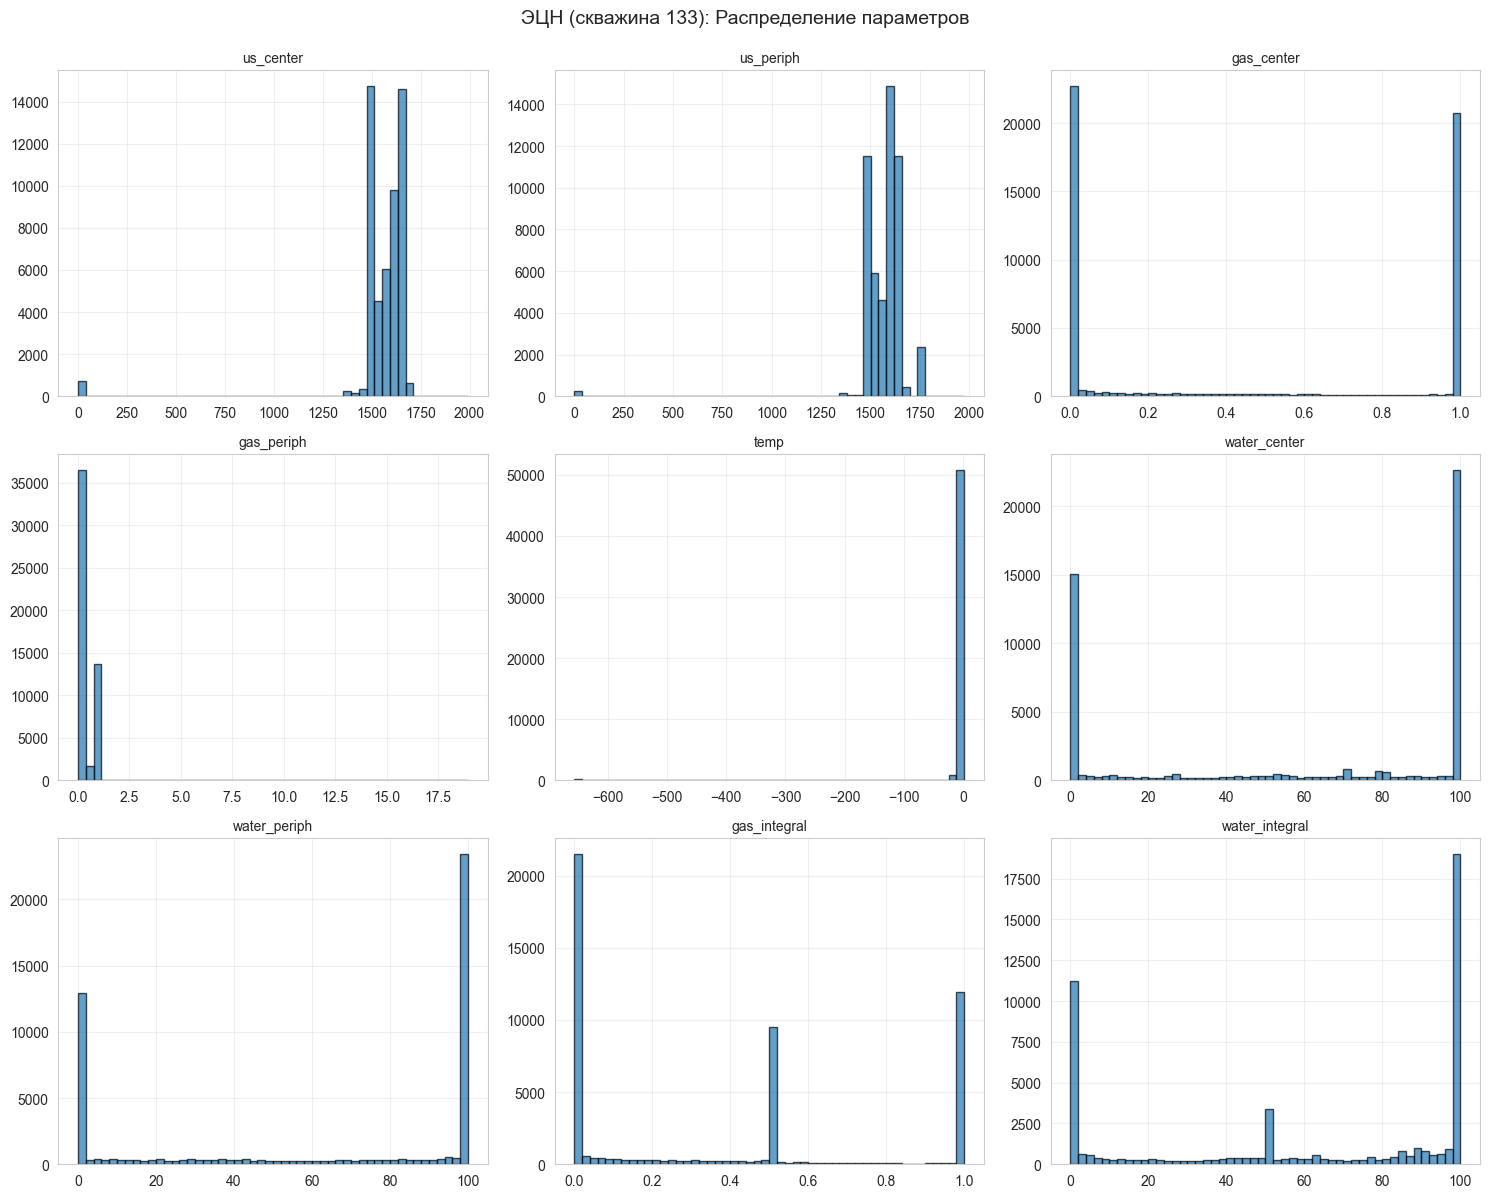

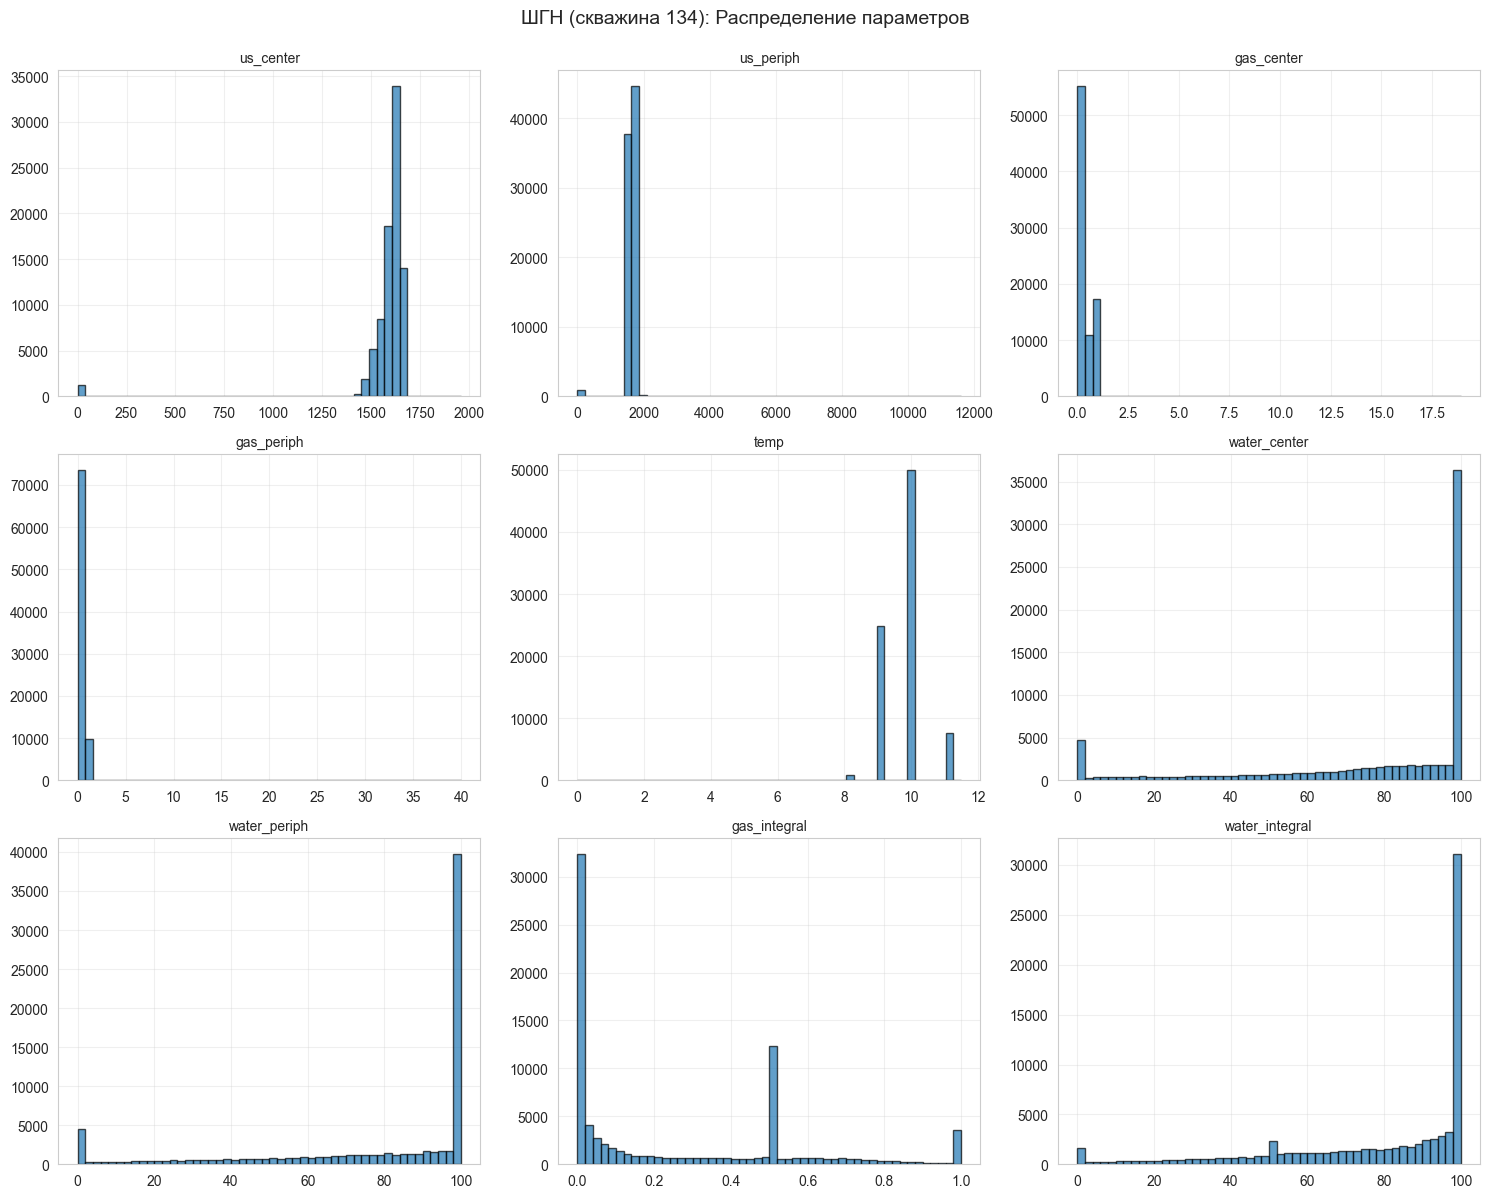

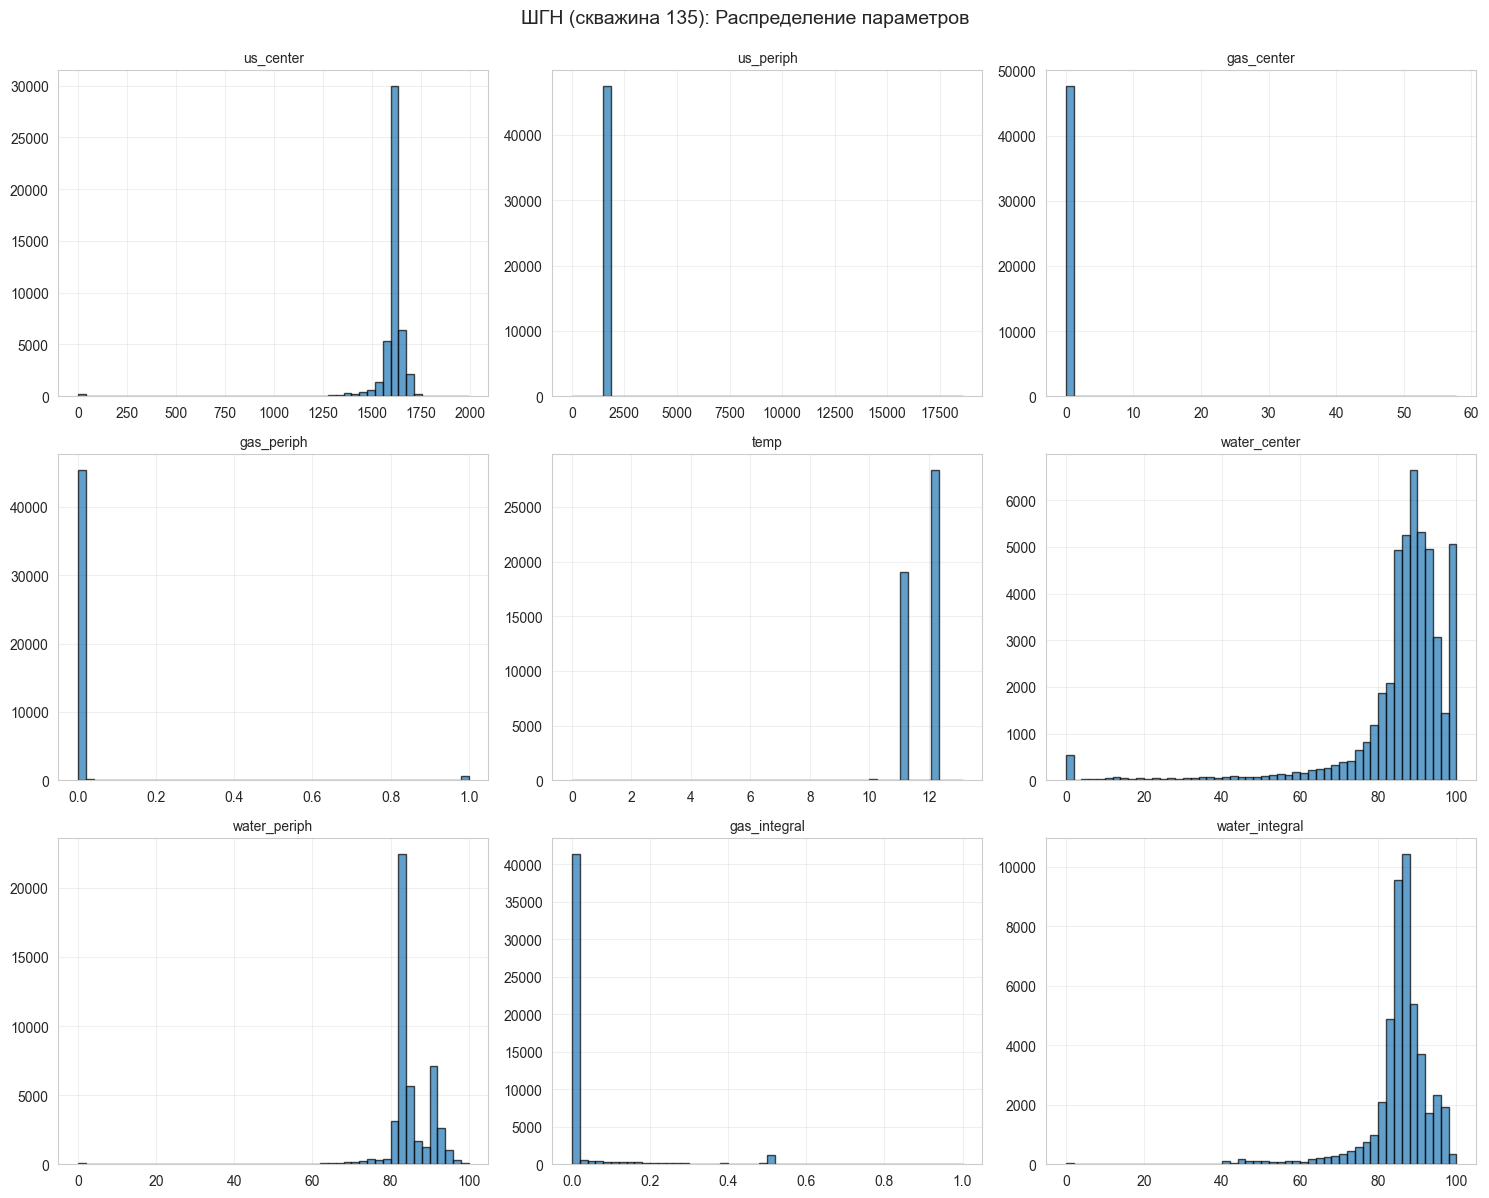

In [15]:
def plot_distributions(df, title):
    fig, axes = plt.subplots(3, 3, figsize=(15, 12))
    fig.suptitle(title, fontsize=14, y=0.995)

    for idx, col in enumerate(FEATURE_COLUMNS):
        ax = axes[idx // 3, idx % 3]
        ax.hist(df[col].dropna(), bins=50, edgecolor="black", alpha=0.7)
        ax.set_title(col, fontsize=10)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


plot_distributions(df_ecn, "ЭЦН (скважина 133): Распределение параметров")
plot_distributions(df_shgn_134, "ШГН (скважина 134): Распределение параметров")
plot_distributions(df_shgn_135, "ШГН (скважина 135): Распределение параметров")

### 2. Временные ряды и паттерны

In [16]:
def plot_timeseries(df, title, subset_hours=None, highlight_anomalies=True, max_gap_hours=12):
    subset = df.copy()
    if subset_hours:
        start = df["timestamp"].min()
        subset = df[df["timestamp"] <= start + pd.Timedelta(hours=subset_hours)]

    subset["time_diff"] = subset["timestamp"].diff()
    large_gaps = subset[subset["time_diff"] > pd.Timedelta(hours=max_gap_hours)].index

    fig, axes = plt.subplots(9, 1, figsize=(16, 20 if subset_hours else 12), sharex=True)

    for idx, col in enumerate(FEATURE_COLUMNS):
        ax = axes[idx]
        ax.plot(subset["timestamp"], subset[col], alpha=0.7, linewidth=0.8)

        for gap_idx in large_gaps:
            ax.axvline(subset.loc[gap_idx, "timestamp"], color="gray", linestyle="--", alpha=0.3, linewidth=1)

        if highlight_anomalies:
            if col == "temp":
                bad = subset[subset[col] < -50]
            elif "gas" in col:
                bad = subset[subset[col] > 1]
            elif "water" in col:
                bad = subset[subset[col] > 100]
            elif "us" in col:
                bad = subset[subset[col] > 2000]

            if not bad.empty:
                ax.scatter(bad["timestamp"], bad[col], color="red", s=15, zorder=5)

        ax.set_ylabel(col, rotation=0, ha="right", fontsize=9)
        ax.grid(True, alpha=0.3)

    axes[-1].set_xlabel("Время")
    fig.suptitle(title, fontsize=14, y=0.995)
    plt.tight_layout()
    plt.show()


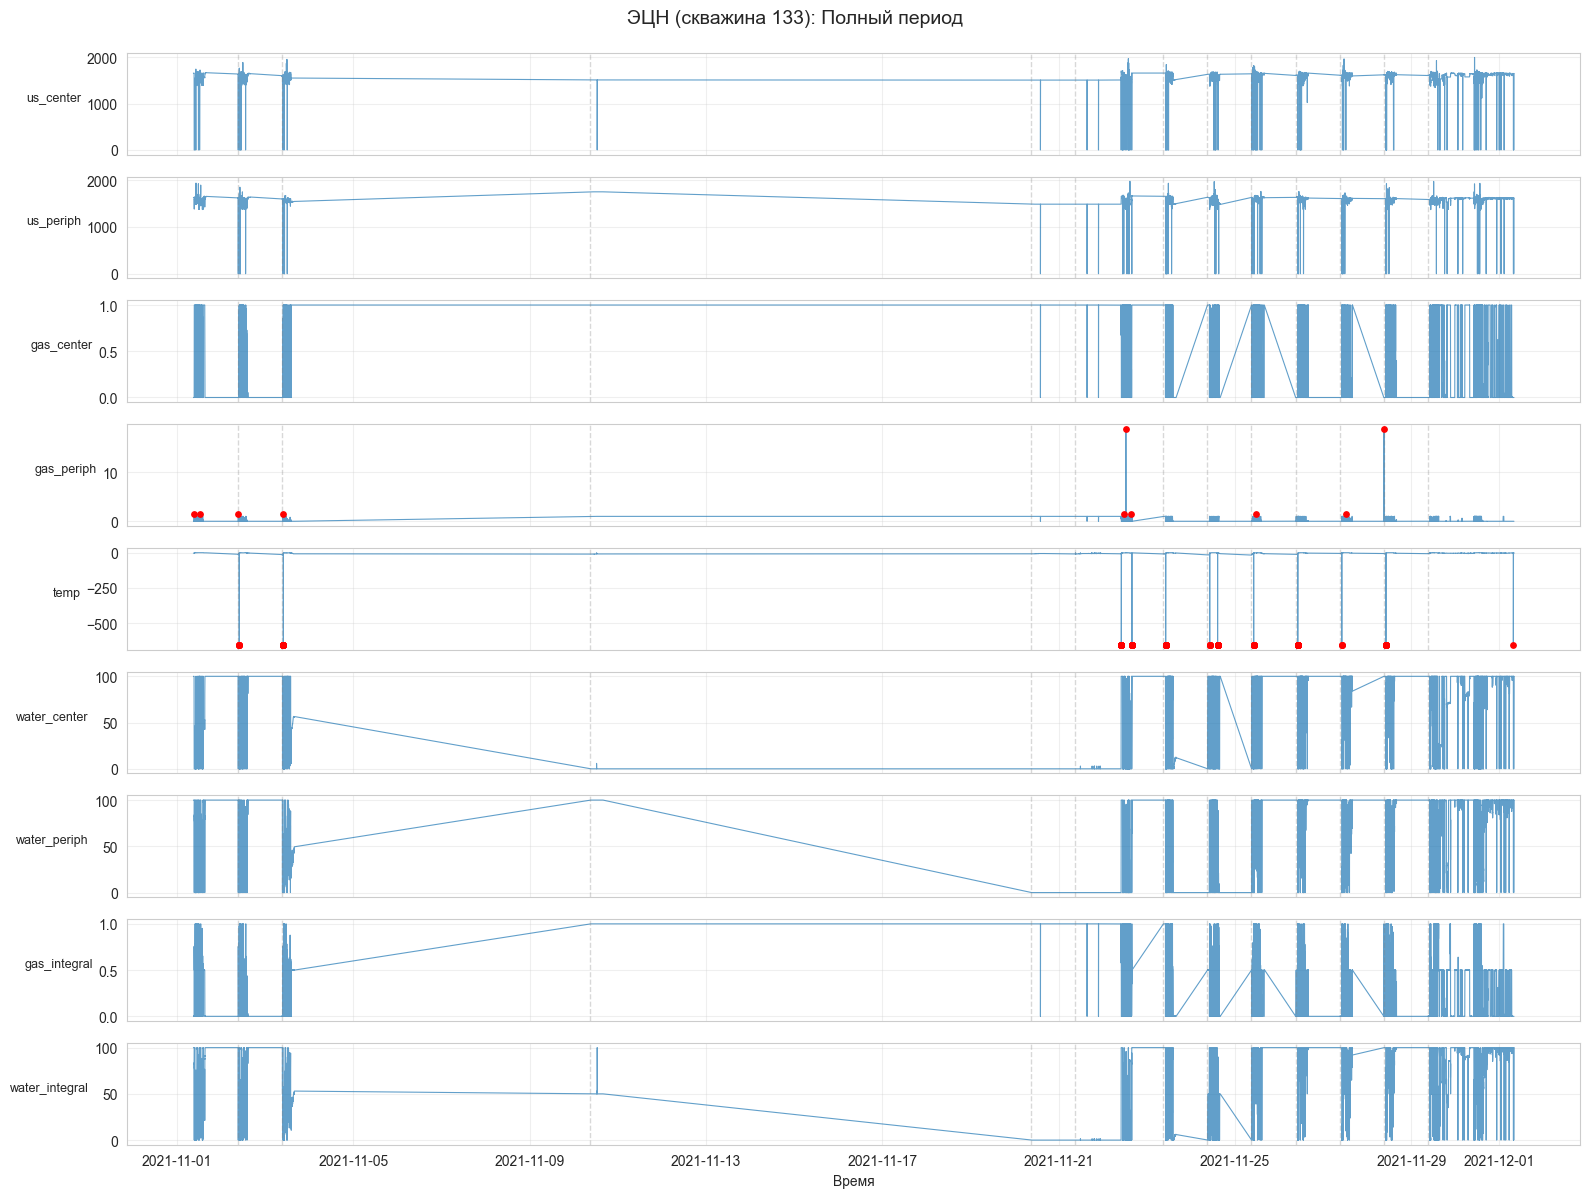

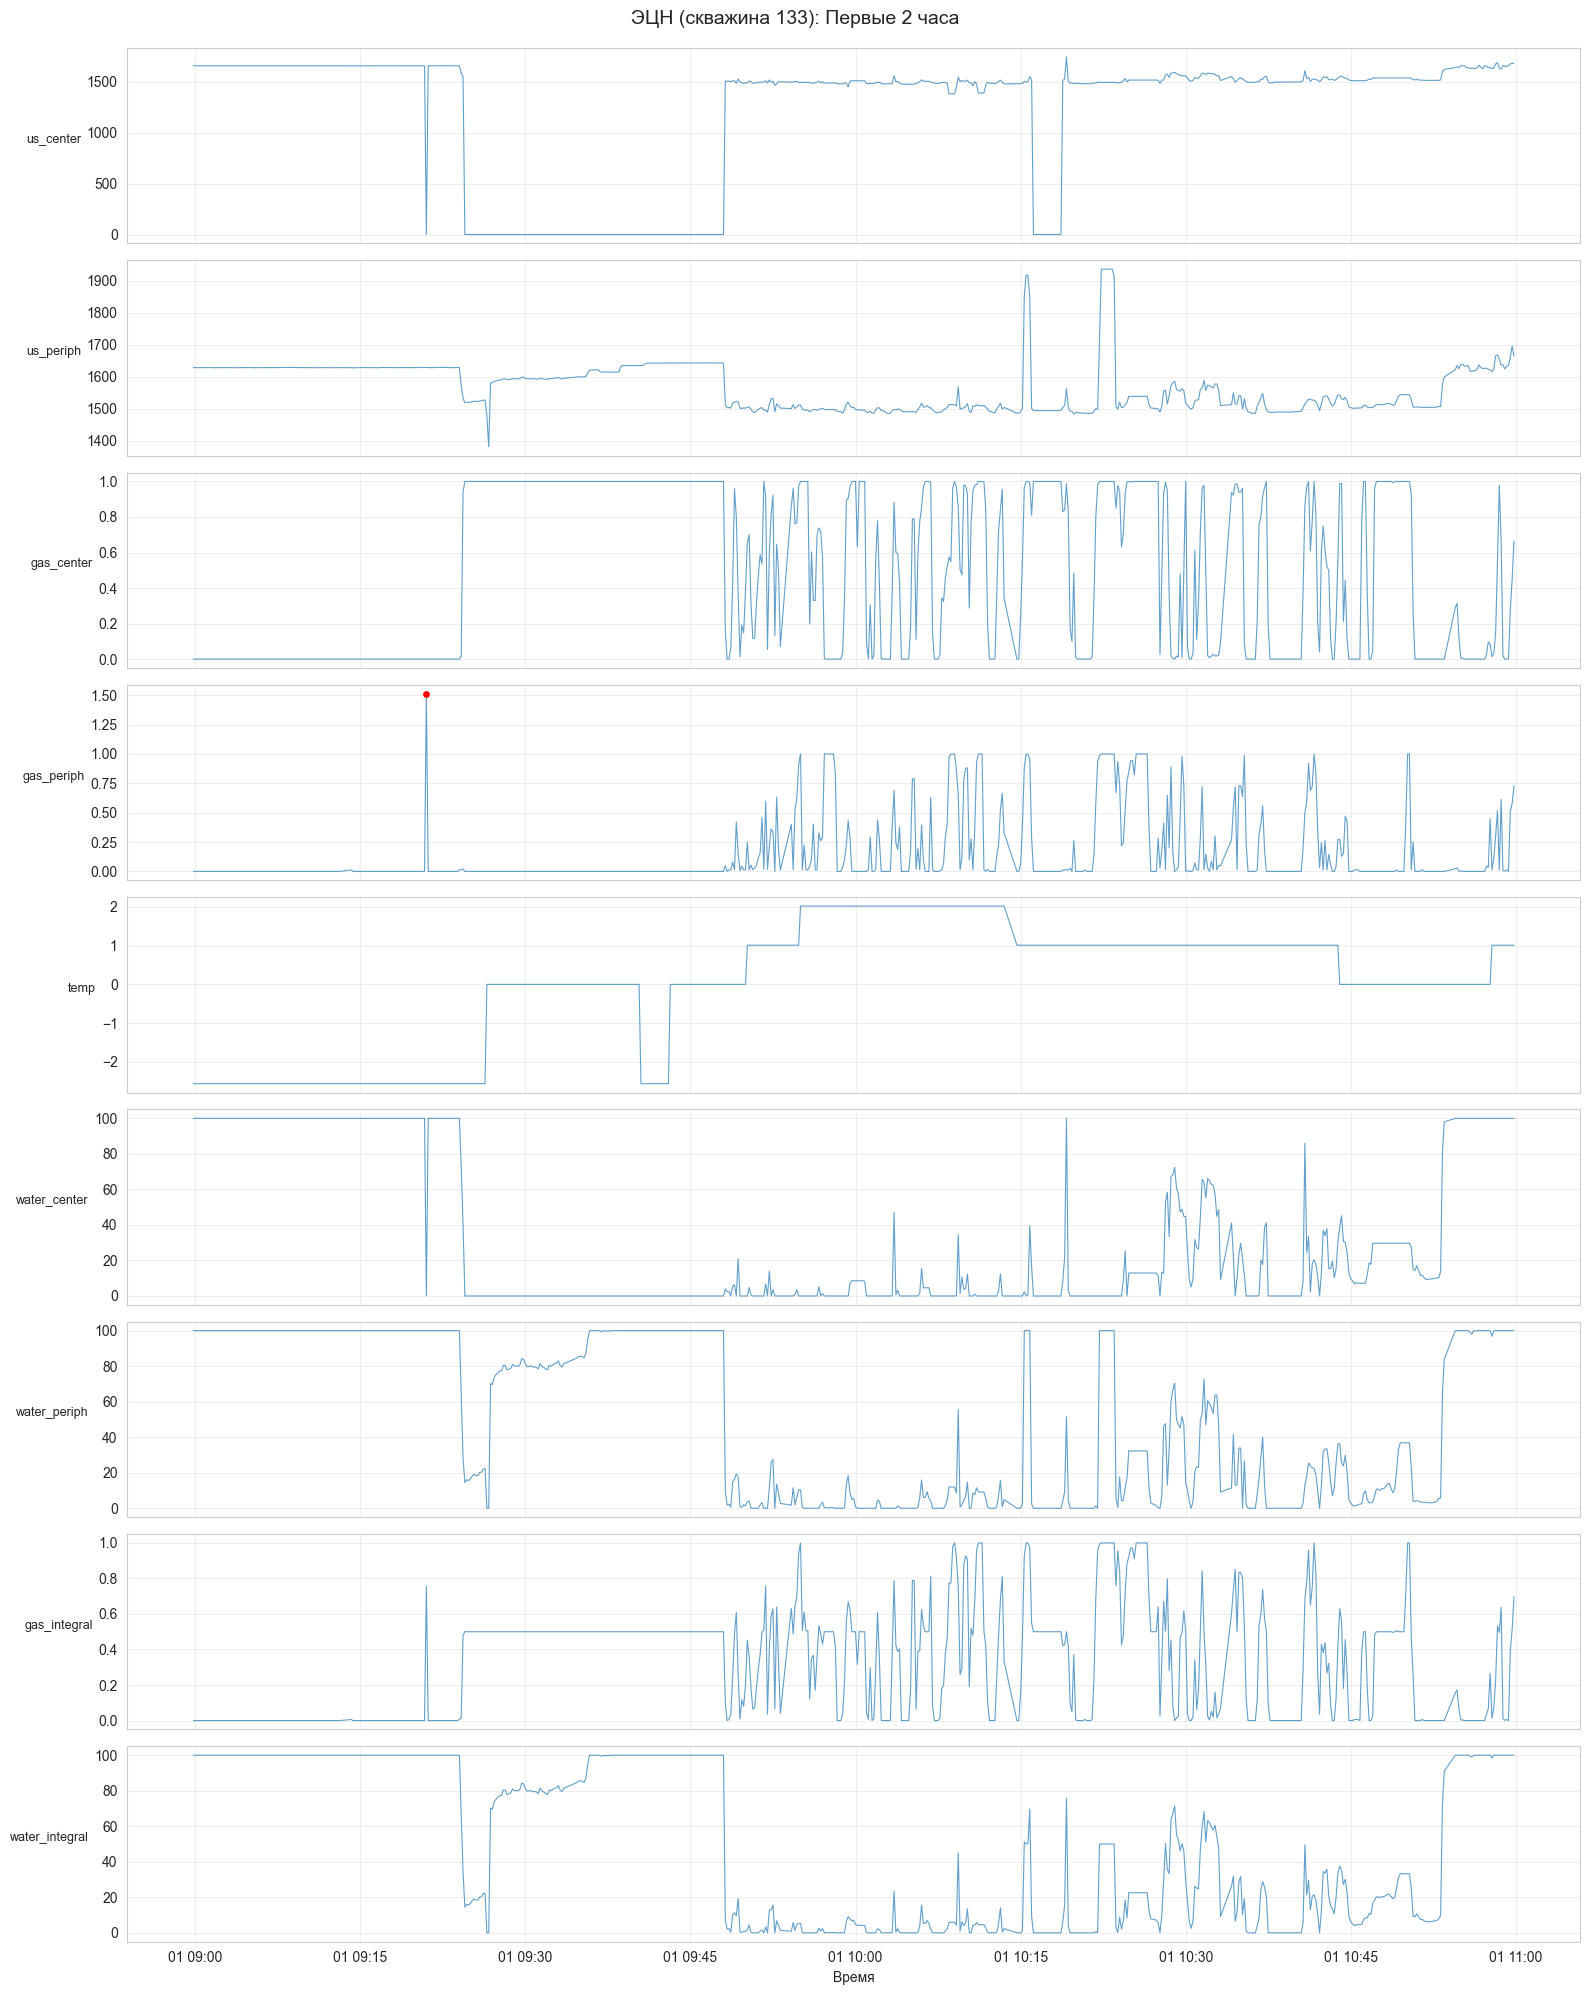

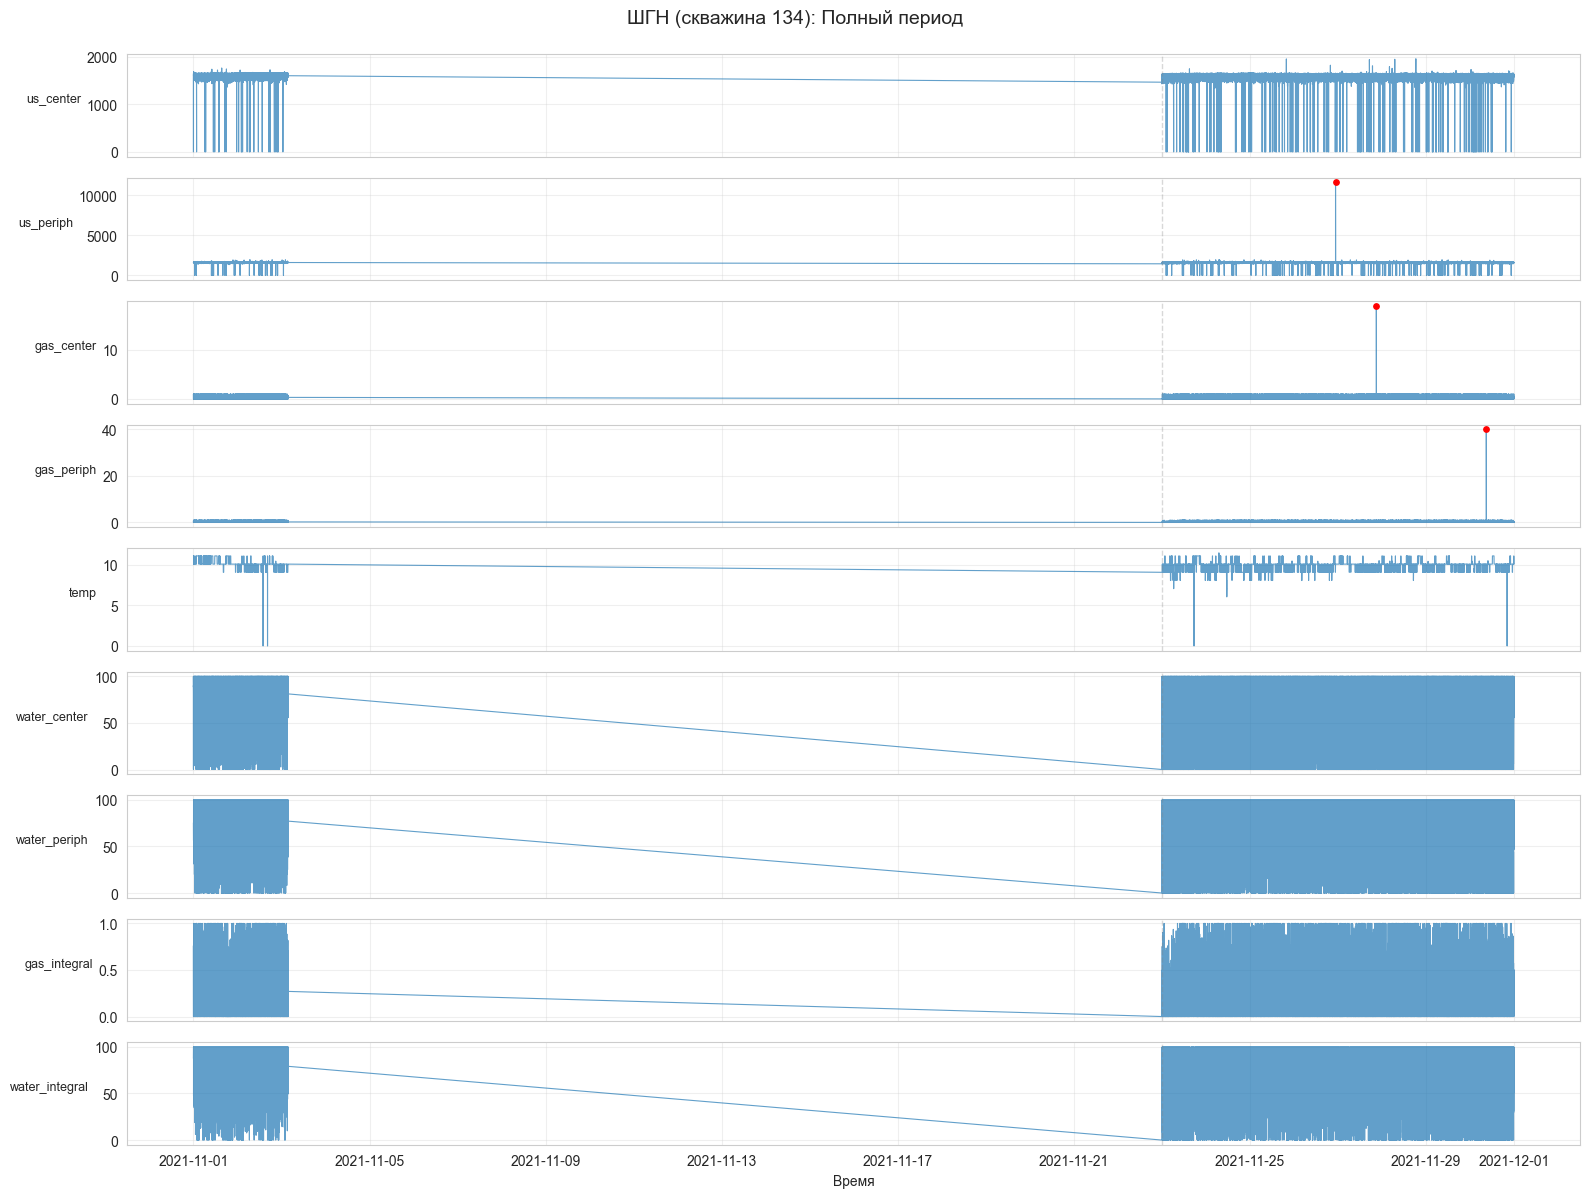

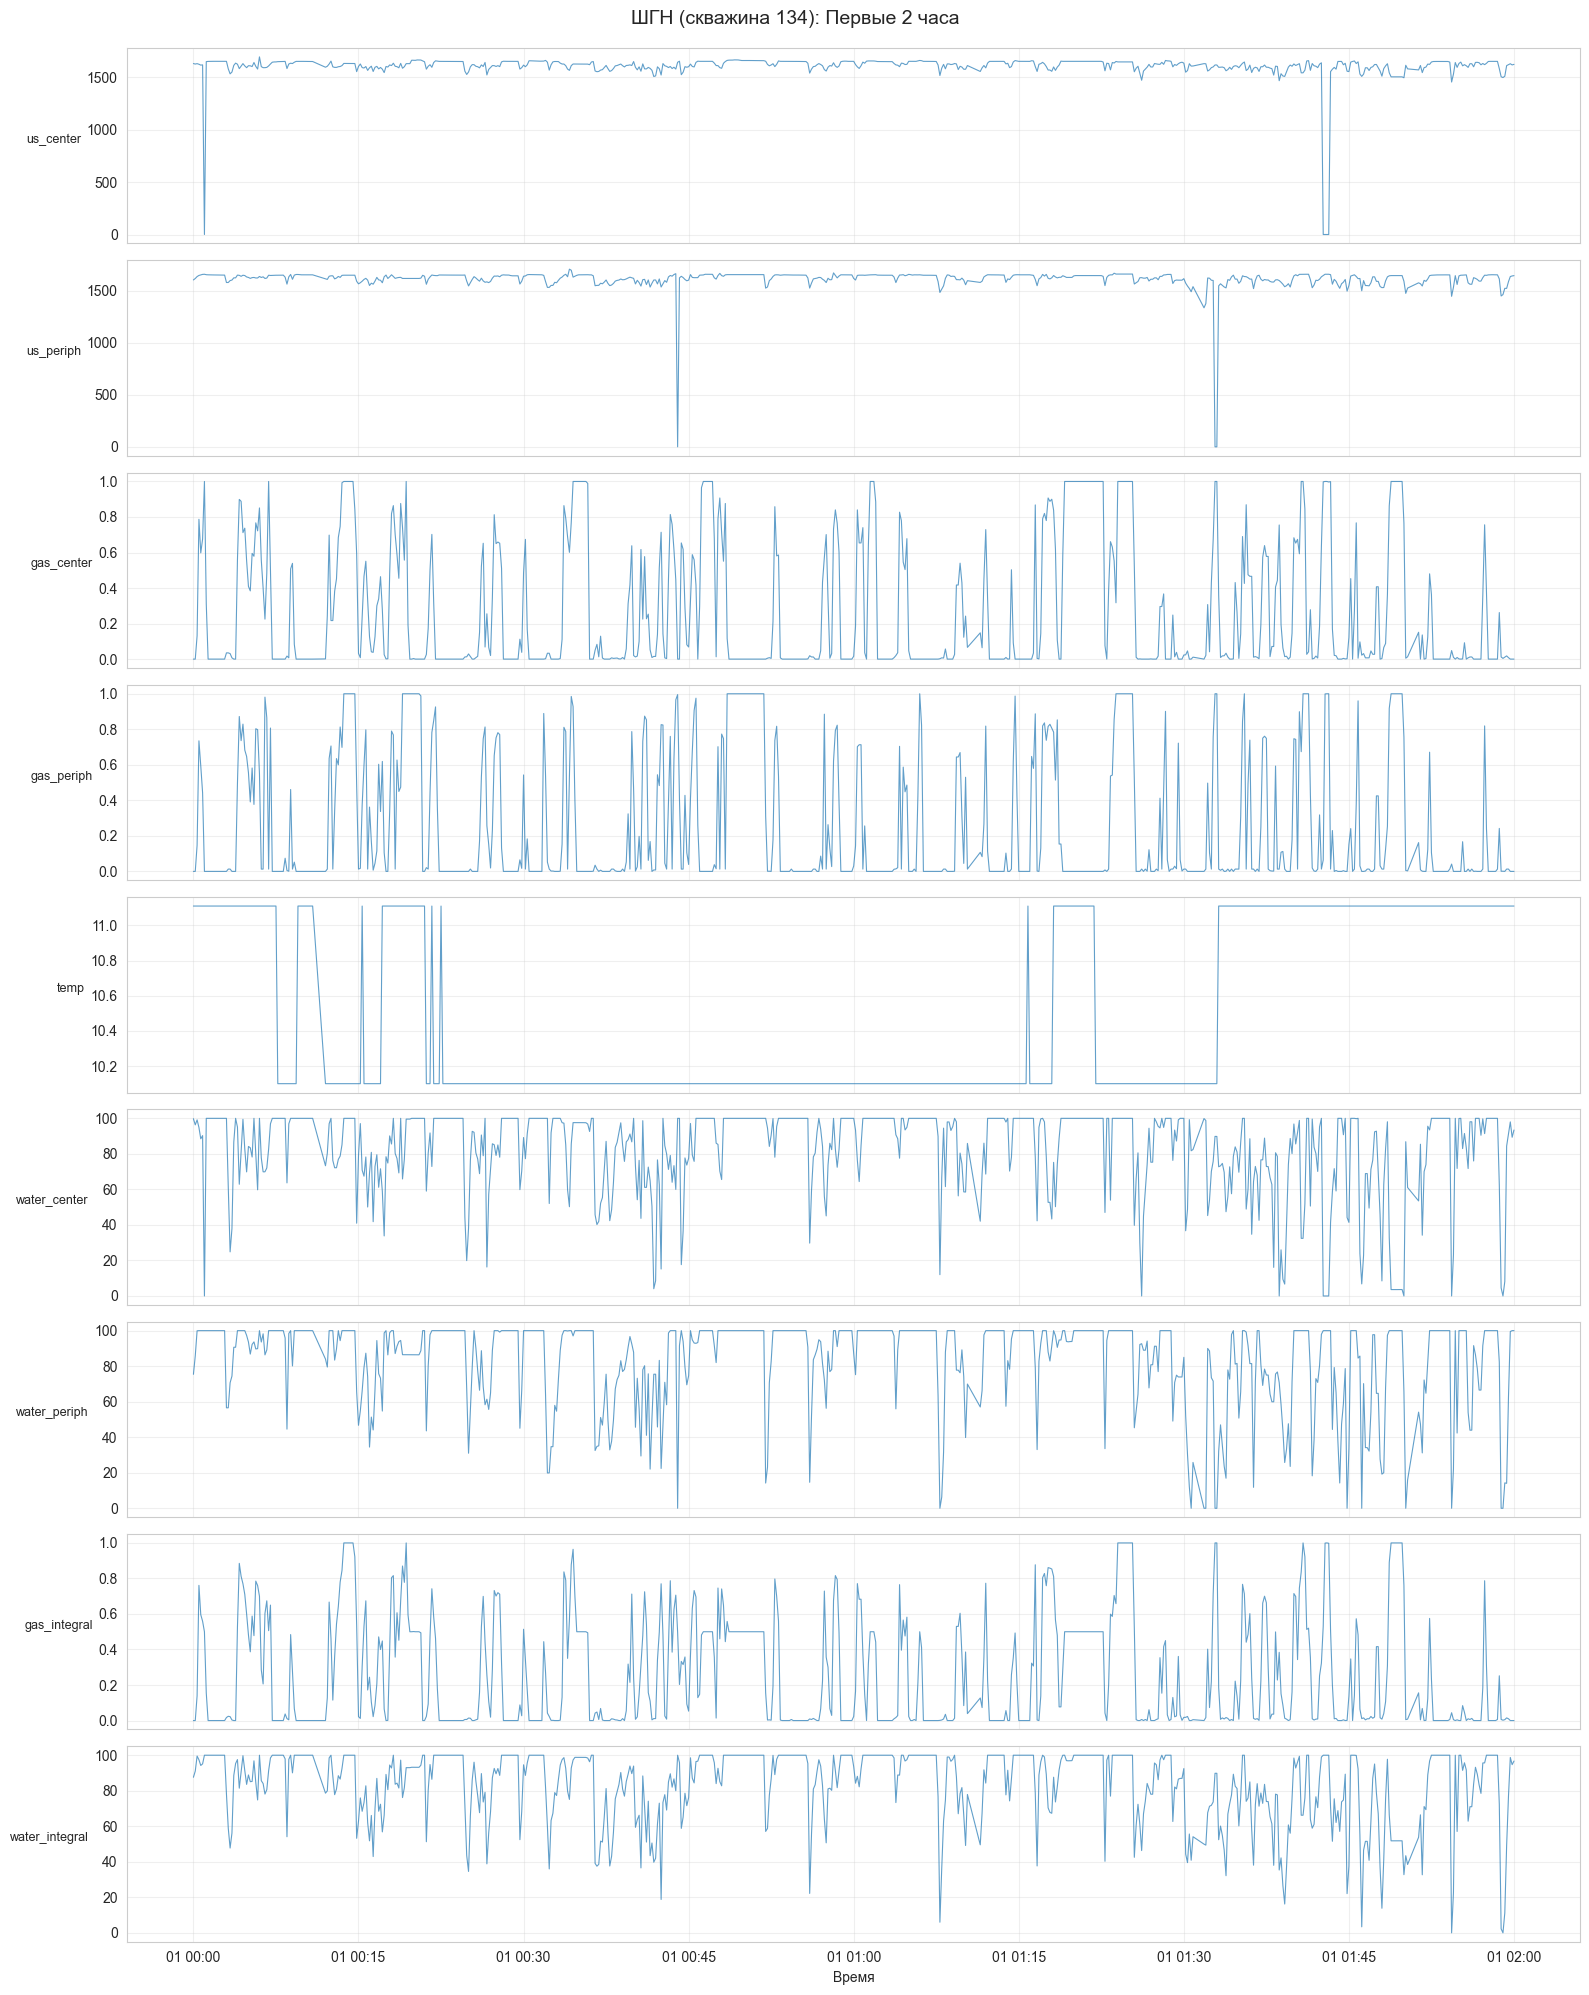

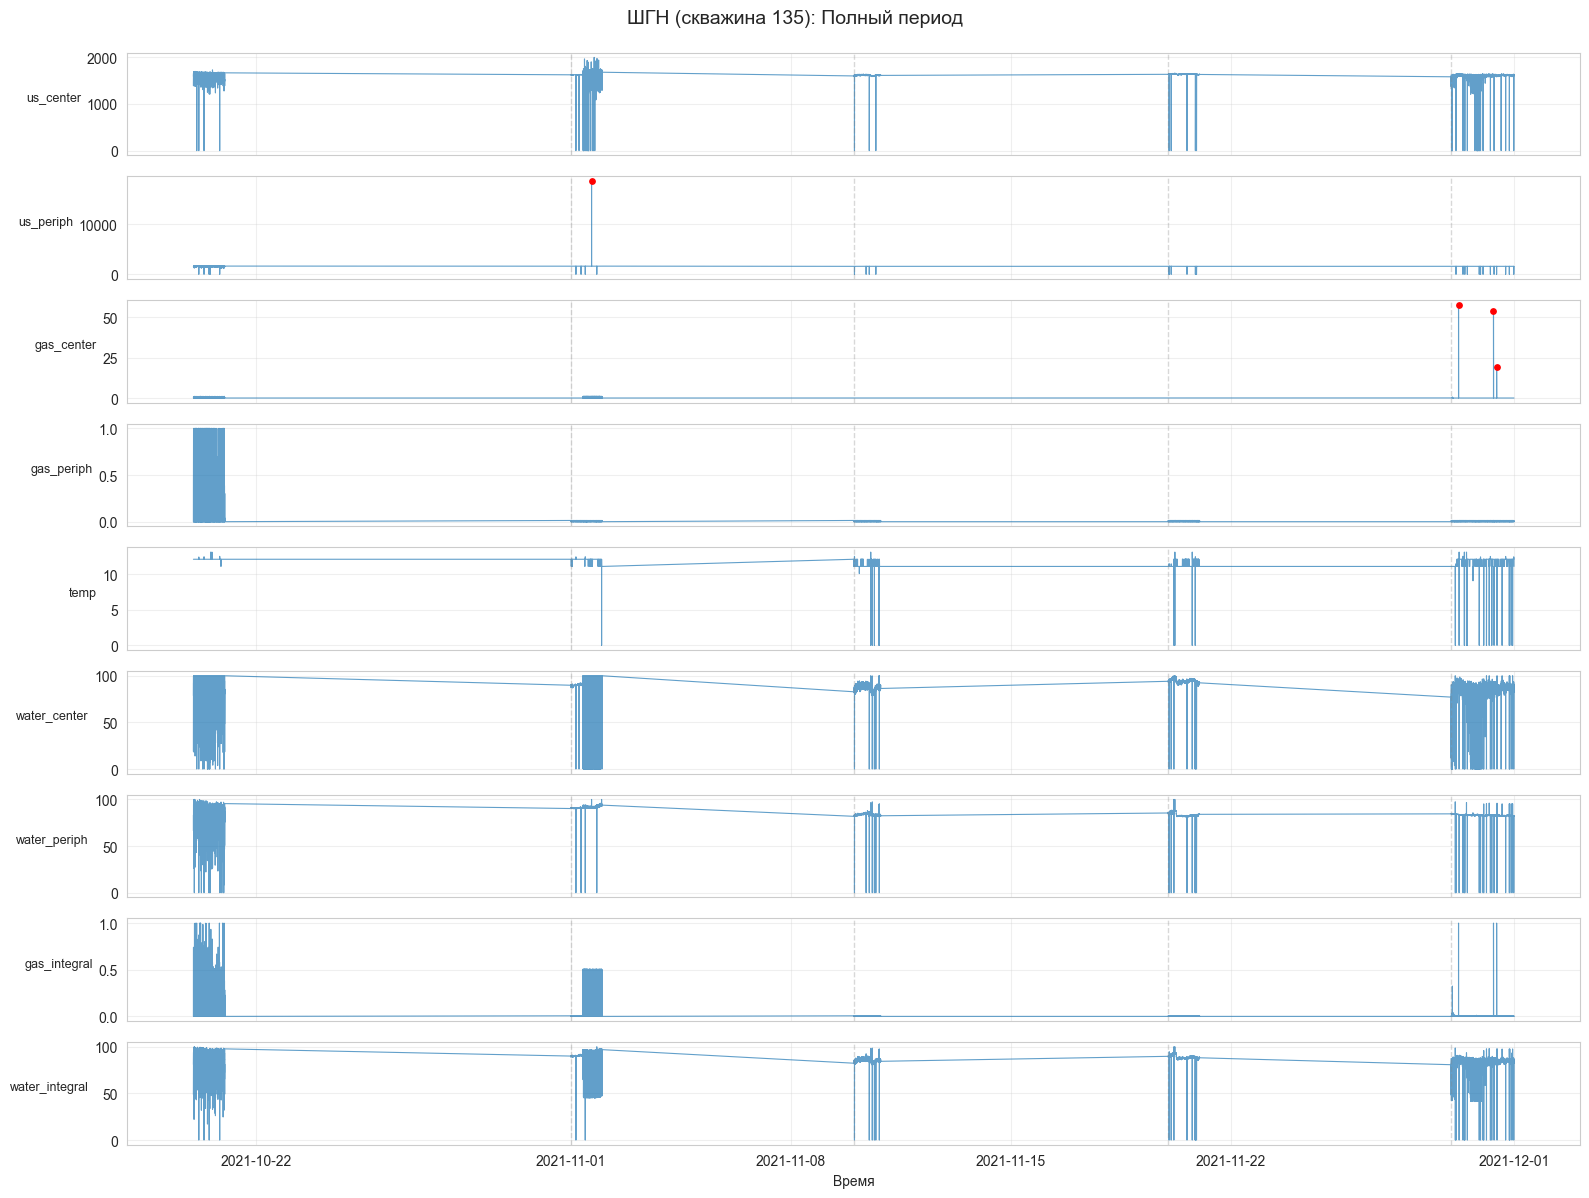

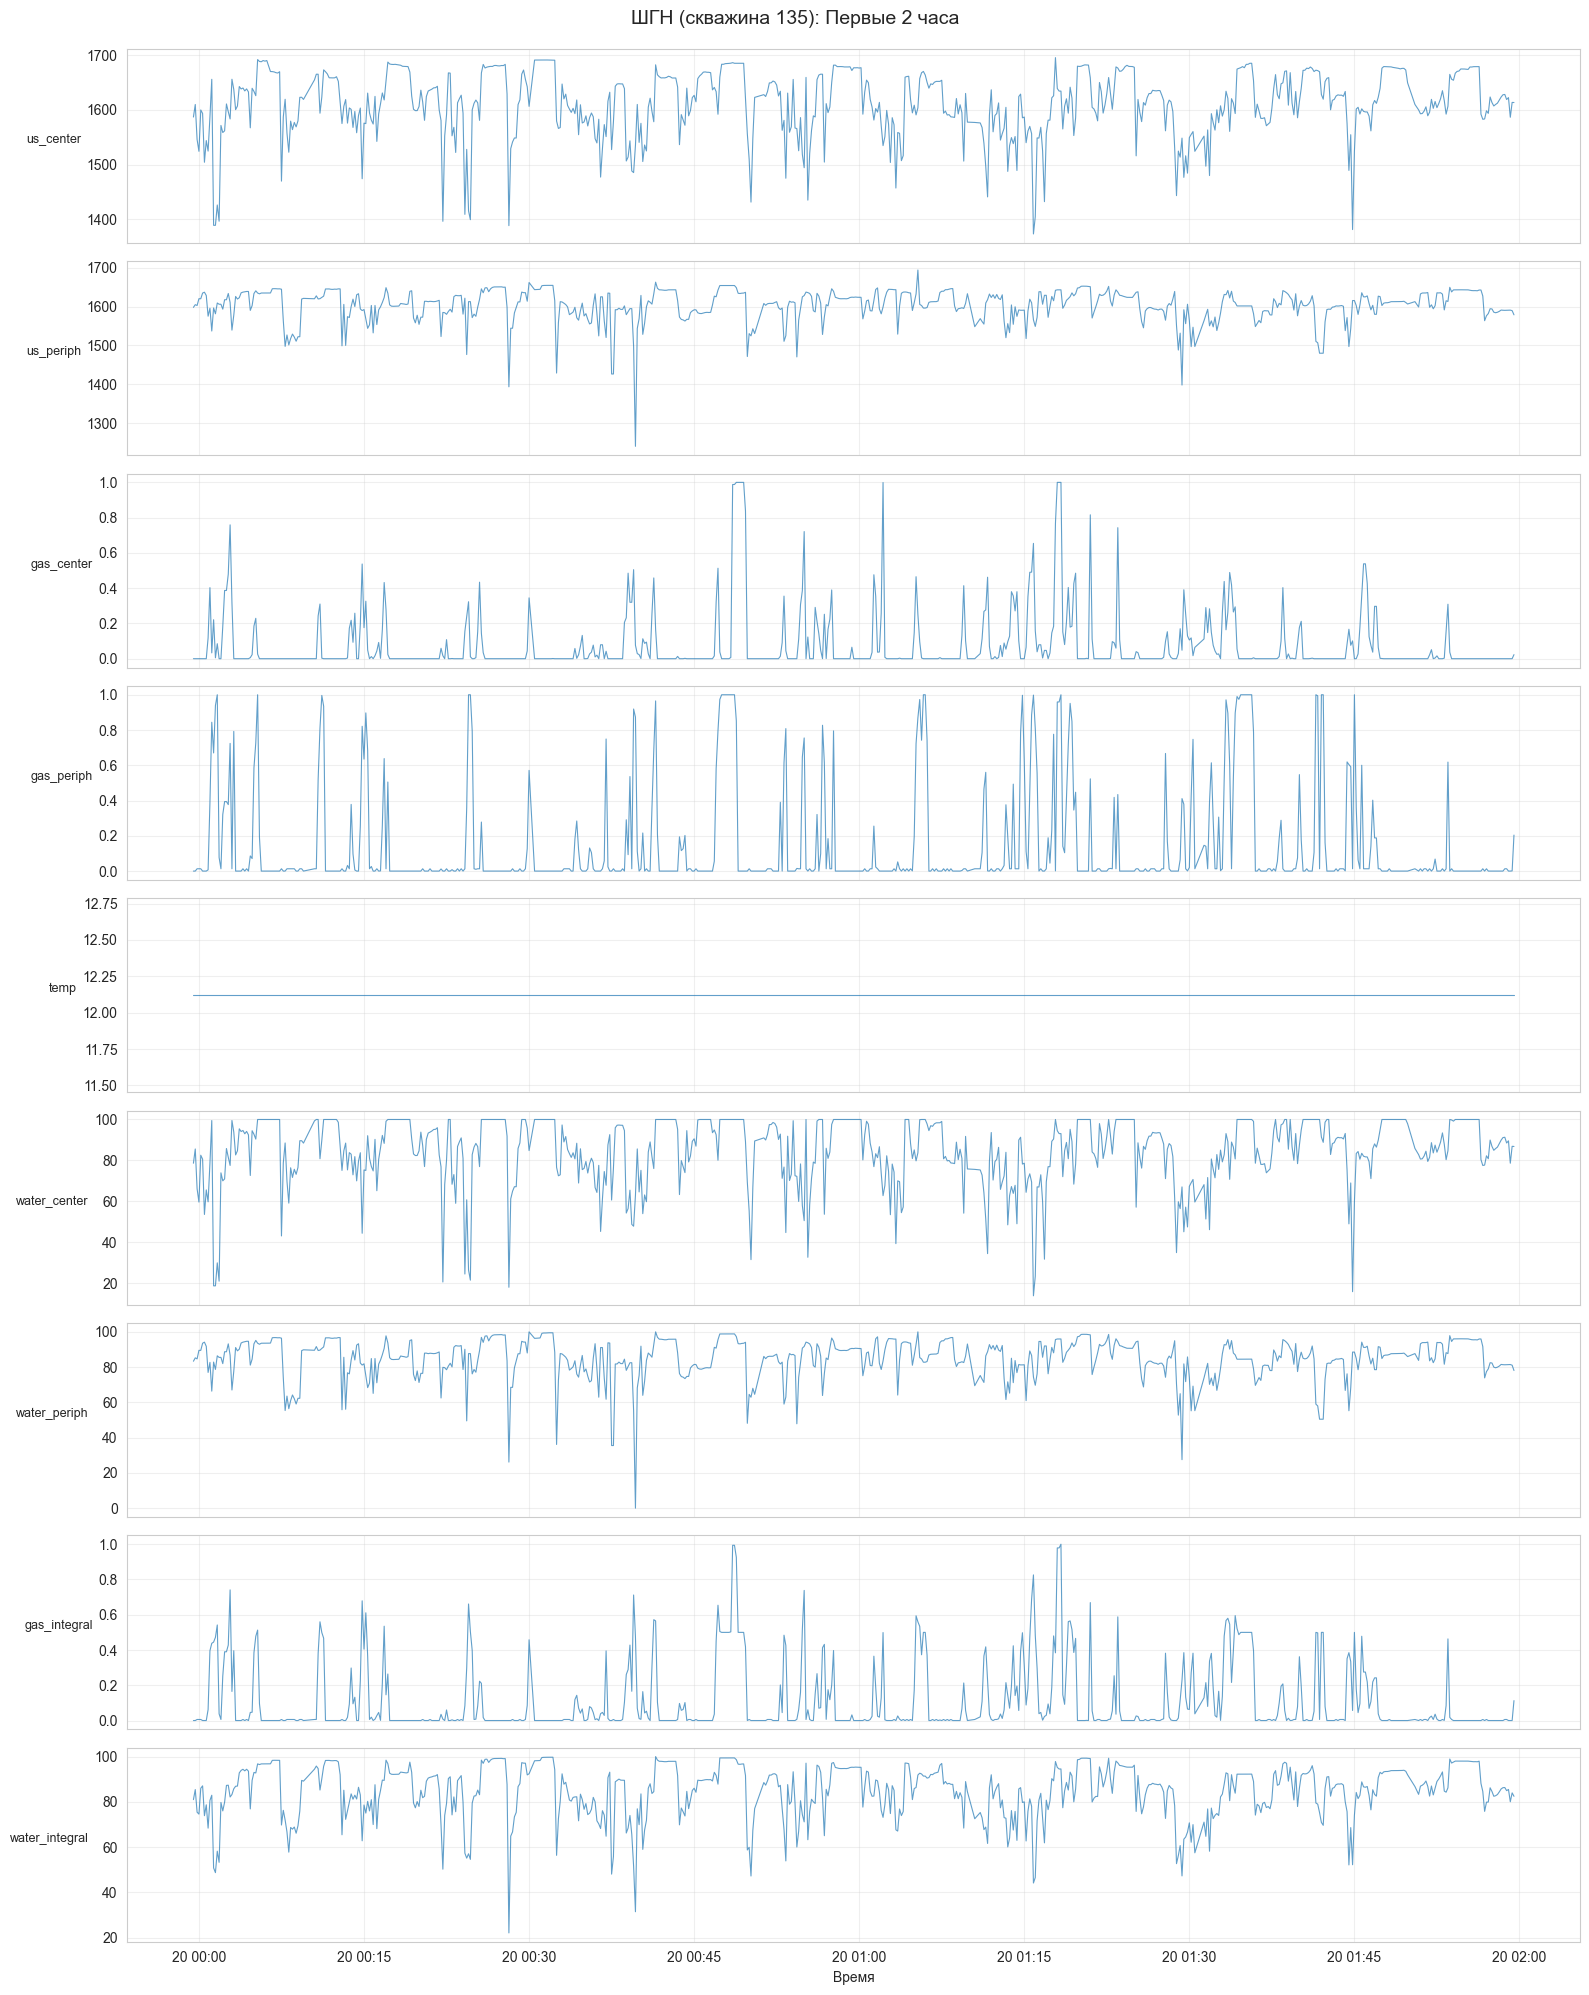

In [17]:
plot_timeseries(df_ecn, "ЭЦН (скважина 133): Полный период")
plot_timeseries(df_ecn, "ЭЦН (скважина 133): Первые 2 часа", subset_hours=2)

plot_timeseries(df_shgn_134, "ШГН (скважина 134): Полный период")
plot_timeseries(df_shgn_134, "ШГН (скважина 134): Первые 2 часа", subset_hours=2)

plot_timeseries(df_shgn_135, "ШГН (скважина 135): Полный период")
plot_timeseries(df_shgn_135, "ШГН (скважина 135): Первые 2 часа", subset_hours=2)


In [18]:
def analyze_shgn_cycle(df, col="water_center"):
    ts = df.set_index("timestamp")[col].dropna()

    intervals = ts.index.to_series().diff().dt.total_seconds().dropna()
    fs = 1 / intervals.median()

    ts_values = ts.values
    ts_detrend = signal.detrend(ts_values)

    f, Pxx = signal.periodogram(ts_detrend, fs=fs)

    f_min, f_max = 1 / (10 * 60), 1 / (5 * 60)
    mask = (f >= f_min) & (f <= f_max)

    if mask.sum() == 0:
        print(f"Пиков в диапазоне 5-10 мин не найдено для {col}")
        return None

    peak_idx = np.argmax(Pxx[mask])
    peak_freq = f[mask][peak_idx]
    period_min = 1 / peak_freq / 60

    _, ax = plt.subplots(figsize=(10, 4))
    ax.semilogy(f[mask], Pxx[mask])
    ax.axvline(peak_freq, color="red", linestyle="--", label=f"Пик: {period_min:.1f} мин")
    ax.set_xlabel("Частота (Гц)")
    ax.set_ylabel("Спектральная плотность")
    ax.set_title(f"Спектр {col}: период {period_min:.1f} мин")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.show()

    return period_min

Анализ циклов ШГН (скважина 134)

Анализ water_center:


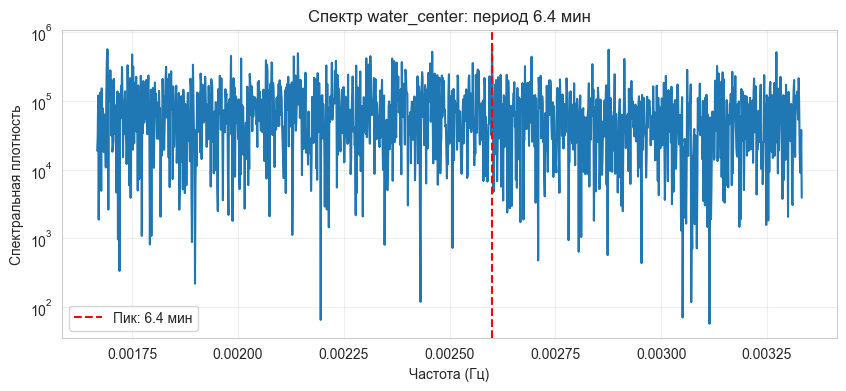

Доминирующий период: 6.4 мин

Анализ gas_center:


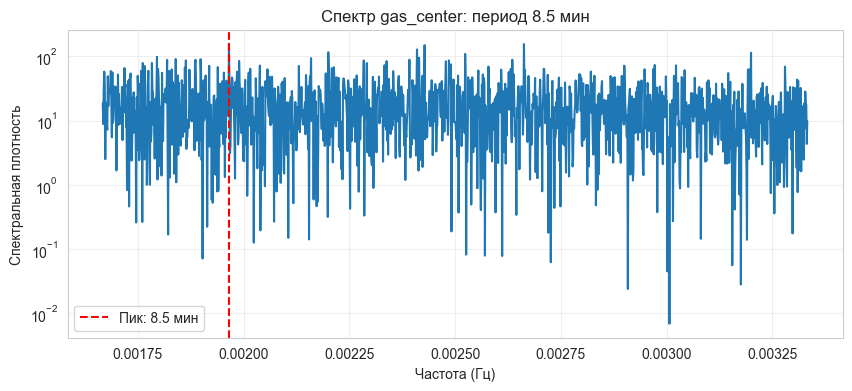

Доминирующий период: 8.5 мин

Анализ us_center:


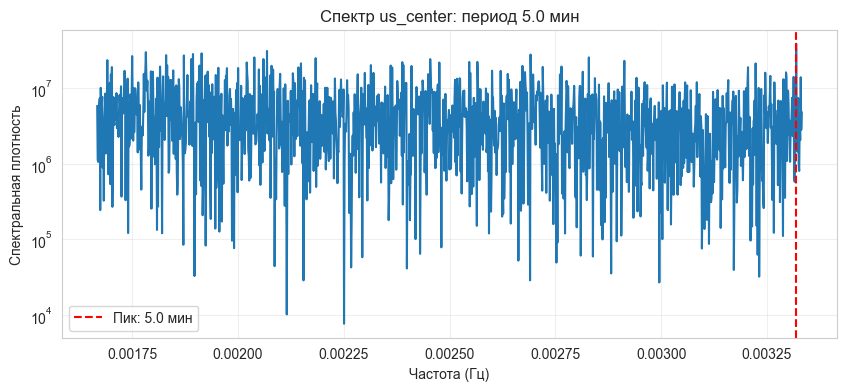

Доминирующий период: 5.0 мин

Анализ циклов ШГН (скважина 135)

Анализ water_center:


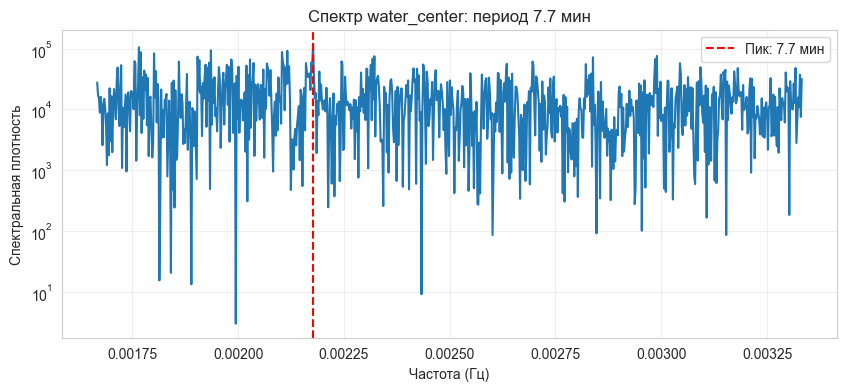

Доминирующий период: 7.7 мин

Анализ gas_center:


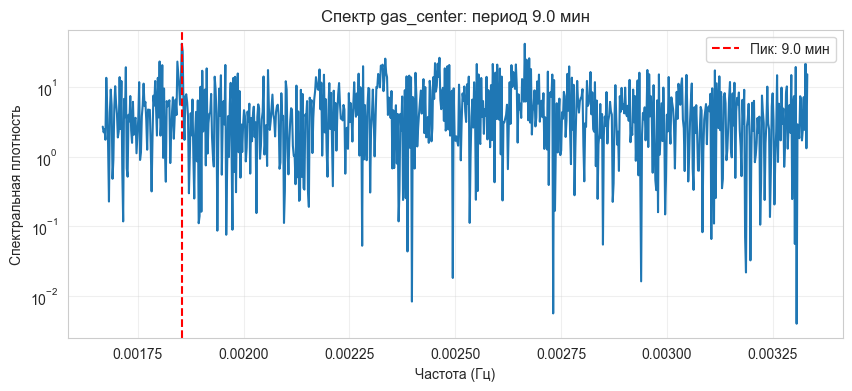

Доминирующий период: 9.0 мин

Анализ us_center:


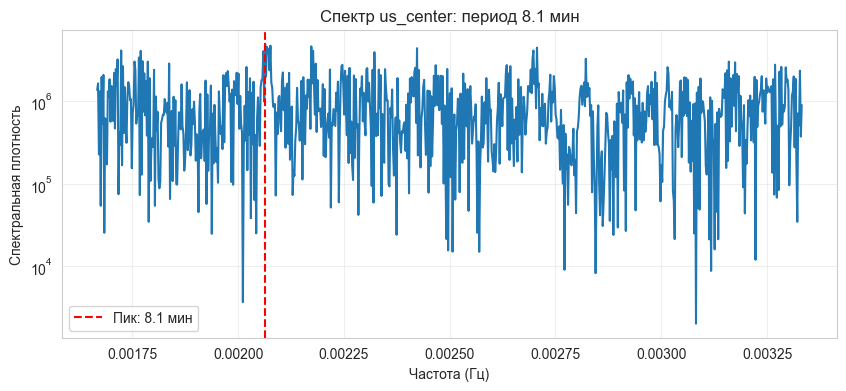

Доминирующий период: 8.1 мин


In [19]:
print("=" * 70)
print("Анализ циклов ШГН (скважина 134)")
print("=" * 70)
for col in ["water_center", "gas_center", "us_center"]:
    print(f"\nАнализ {col}:")
    period = analyze_shgn_cycle(df_shgn_134, col=col)
    if period:
        print(f"Доминирующий период: {period:.1f} мин")

print("\n" + "=" * 70)
print("Анализ циклов ШГН (скважина 135)")
print("=" * 70)
for col in ["water_center", "gas_center", "us_center"]:
    print(f"\nАнализ {col}:")
    period = analyze_shgn_cycle(df_shgn_135, col=col)
    if period:
        print(f"Доминирующий период: {period:.1f} мин")


### Анализ циклов работы ШГН:

**Скважина 134:**
- water_center: 6.4 мин
- gas_center: 8.5 мин  
- us_center: 5.0 мин
- Средний период: ~6.6 мин

**Скважина 135:**
- water_center: 7.7 мин
- gas_center: 9.0 мин
- us_center: 8.1 мин
- Средний период: ~8.3 мин

**Вывод:** Скважины имеют разные циклы работы (134 быстрее, 135 медленнее).

### Анализ временных рядов:

**ЭЦН (скважина 133):**
- Периодическая работа: данные только с 09:00 до 16:00
- Пропуски в данных = дни без работы (техобслуживание/остановка)
- Непрерывные периоды работы: 1-3 ноября, 10 ноября, 20-30 ноября
- Во время работы: стабильный поток, us_center ~1500-1600

**ШГН (скважины 134 и 135):**
- Работают круглосуточно и независимо
- Циклическая работа с разными периодами (см. выше)
- Антифаза между water_* и gas_* (когда газ растет, вода падает)
- Видны периоды остановки/техобслуживания на графиках

### 3. Очистка данных от выбросов и аномалий

In [ ]:
df_ecn_clean = df_ecn[(df_ecn["us_center"] > 0) & (df_ecn["us_periph"] > 0)].reset_index(drop=True)

df_shgn_134_clean = df_shgn_134[df_shgn_134["us_center"] > 0].reset_index(drop=True)

df_shgn_135_clean = df_shgn_135[df_shgn_135["us_center"] > 0].reset_index(drop=True)

print(f"ЭЦН (133):  {len(df_ecn):,} → {len(df_ecn_clean):,} ({len(df_ecn_clean) / len(df_ecn) * 100:.1f}%)")
print(
    f"ШГН (134):  {len(df_shgn_134):,} → {len(df_shgn_134_clean):,} ({len(df_shgn_134_clean) / len(df_shgn_134) * 100:.1f}%)"
)
print(
    f"ШГН (135):  {len(df_shgn_135):,} → {len(df_shgn_135_clean):,} ({len(df_shgn_135_clean) / len(df_shgn_135) * 100:.1f}%)"
)

ЭЦН (133):  51,908 → 50,957 (98.2%)
ШГН (134):  83,486 → 82,311 (98.6%)
ШГН (135):  47,631 → 47,453 (99.6%)


### 4. Корреляционный анализ

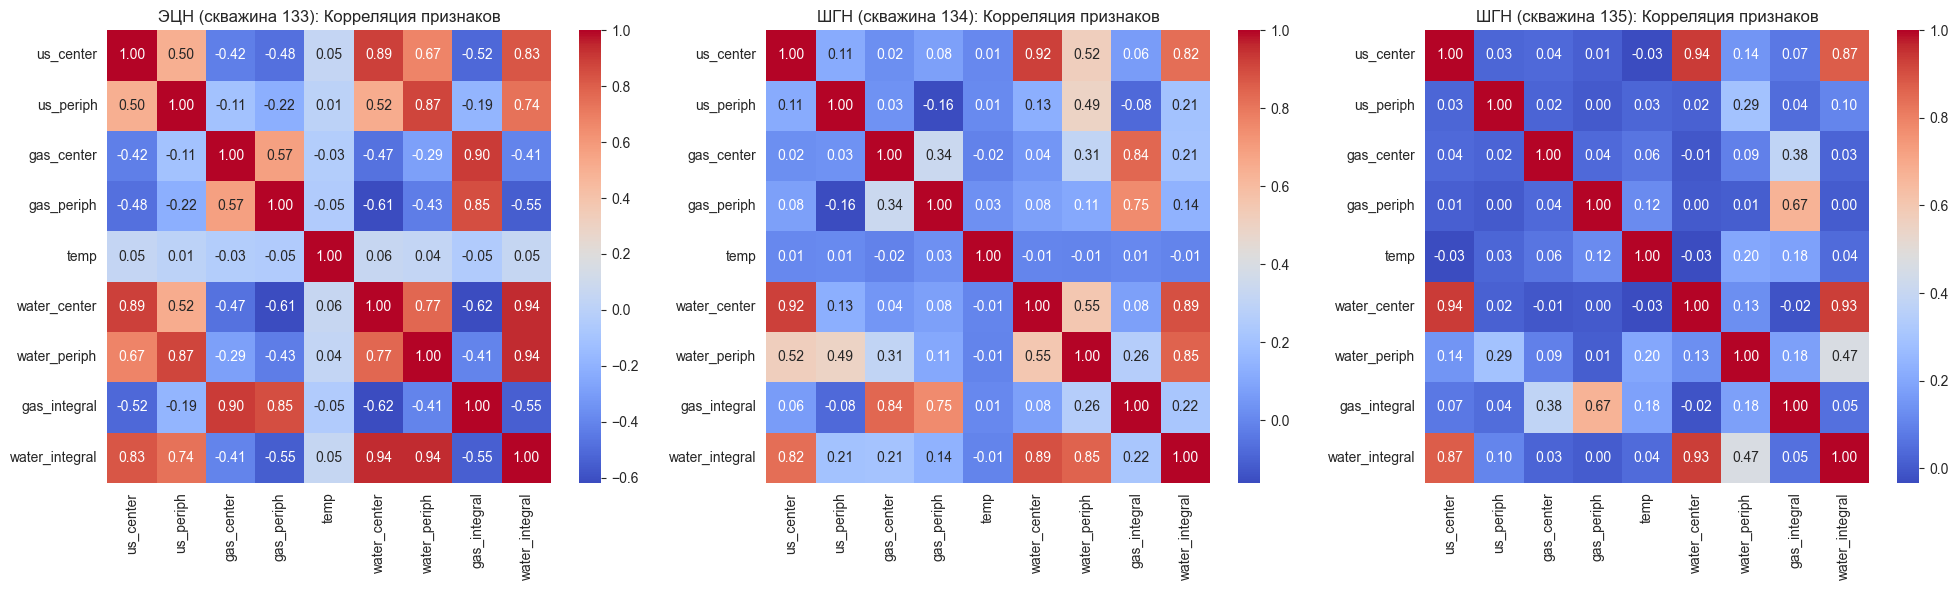

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.heatmap(df_ecn_clean[FEATURE_COLUMNS].corr(), annot=True, fmt=".2f", cmap="coolwarm", ax=axes[0])
axes[0].set_title("ЭЦН (скважина 133): Корреляция признаков")

sns.heatmap(df_shgn_134_clean[FEATURE_COLUMNS].corr(), annot=True, fmt=".2f", cmap="coolwarm", ax=axes[1])
axes[1].set_title("ШГН (скважина 134): Корреляция признаков")

sns.heatmap(df_shgn_135_clean[FEATURE_COLUMNS].corr(), annot=True, fmt=".2f", cmap="coolwarm", ax=axes[2])
axes[2].set_title("ШГН (скважина 135): Корреляция признаков")

plt.tight_layout()
plt.show()


### Корреляционный анализ

**ЭЦН (скважина 133) — стабильный режим:**

| Признаки                          | Корреляция        | Интерпретация                                         |
| --------------------------------- | ----------------- | ----------------------------------------------------- |
| `water_center` ↔ `water_periph`   | **0.77**          | Сильная связь — синхронное заполнение сечения         |
| `water_center` ↔ `water_integral` | **0.94**          | Очень сильная — интеграл отражает мгновенное значение |
| `water_periph` ↔ `water_integral` | **0.94**          | Очень сильная                                         |
| `gas_center` ↔ `gas_integral`     | **0.90**          | Очень сильная                                         |
| `us_center` ↔ `water_center`      | **0.89**          | Сильная — скорость УЗ растёт с водой                  |
| `us_periph` ↔ `water_periph`      | **0.87**          | Сильная                                               |
| `us_center` ↔ `us_periph`         | **0.50**          | Умеренная — центр и периферия связаны слабее          |
| `gas_center` ↔ `gas_periph`       | **0.57**          | Умеренная — газ распределён неравномерно              |
| `water_center` ↔ `gas_center`     | **-0.48**         | Антифаза вода/газ                                     |
| `water_periph` ↔ `gas_periph`     | **-0.61**         | Сильная антифаза                                      |
| `water_*` ↔ `gas_integral`        | **-0.52 … -0.62** | Антифаза вода/газ                                     |

**Вывод:** Установившийся режим с чёткой физикой — вода вытесняет газ, интегральные параметры дублируют мгновенные. Высокая предсказуемость.


**ШГН (скважина 134) — циклический режим:**

| Признаки                          | Корреляция    | Интерпретация                               |
| --------------------------------- | ------------- | ------------------------------------------- |
| `water_center` ↔ `water_integral` | **0.95**      | Очень сильная                               |
| `water_periph` ↔ `water_integral` | **0.95**      | Очень сильная                               |
| `us_center` ↔ `water_center`      | **0.92**      | Очень сильная — та же физика, что у ЭЦН     |
| `gas_center` ↔ `gas_integral`     | **0.76**      | Сильная                                     |
| `water_center` ↔ `water_periph`   | **0.56**      | Умеренная — циклы размывают связь           |
| `us_center` ↔ `us_periph`         | **0.11**      | Очень слабая — центр и периферия независимы |
| `gas_center` ↔ `gas_periph`       | **-0.16**     | Слабая отрицательная — газ движется хаотично |
| `temp` ↔ любые признаки           | **~-0.02 … 0.01** | Нет связи — температура стабильна       |

**Вывод:** Циклическая работа (период ~6.6 мин) размывает корреляции между центром и периферией. Газ распределён хаотично. Высокая динамика.


**ШГН (скважина 135) — циклический режим с особенностями:**

| Признаки                          | Корреляция    | Интерпретация                               |
| --------------------------------- | ------------- | ------------------------------------------- |
| `water_center` ↔ `water_integral` | **0.93**      | Очень сильная                               |
| `water_periph` ↔ `water_integral` | **0.93**      | Очень сильная                               |
| `us_center` ↔ `water_center`      | **0.94**      | Очень сильная                               |
| `gas_center` ↔ `gas_integral`     | **0.67**      | Сильная, но слабее чем у 134                |
| `water_center` ↔ `water_periph`   | **0.29**      | Слабая — циклы сильнее размывают связь      |
| `us_center` ↔ `us_periph`         | **-0.04**     | Нет связи — полная независимость            |
| `gas_center` ↔ `gas_periph`       | **0.00**      | Нет связи — газ движется независимо         |
| `temp` ↔ любые признаки           | **~-0.03 … 0.03** | Нет связи                               |

**Вывод:** Циклы более выражены (период ~8.3 мин), связи между центром и периферией почти отсутствуют. Газ распределён хаотично. Скважина работает медленнее, чем 134.


### Выбор признаков

Несмотря на высокую корреляцию интегральных параметров с локальными (0.89-0.94),
все 9 признаков сохранены для обучения модели:
1. Соответствие реальным данным влагомера
2. Автоэнкодер автоматически выявит избыточность через бутылочное горлышко
3. Интегральные параметры могут содержать дополнительную информацию о состоянии потока

### 5. Нормализация данных

In [ ]:
scaler_ecn = StandardScaler()
scaler_shgn = StandardScaler()

df_ecn_normalized = df_ecn_clean.copy()
df_ecn_normalized[FEATURE_COLUMNS] = scaler_ecn.fit_transform(df_ecn_clean[FEATURE_COLUMNS])

df_shgn_combined = pd.concat([df_shgn_134_clean, df_shgn_135_clean], ignore_index=True)

df_shgn_normalized = df_shgn_combined.copy()
df_shgn_normalized[FEATURE_COLUMNS] = scaler_shgn.fit_transform(df_shgn_combined[FEATURE_COLUMNS])

print("Нормализация завершена")
print(
    f"ЭЦН (133):  mean={df_ecn_normalized[FEATURE_COLUMNS].mean().mean():.2f}, std={df_ecn_normalized[FEATURE_COLUMNS].std().mean():.2f}"
)
print(
    f"ШГН (134+135):  mean={df_shgn_normalized[FEATURE_COLUMNS].mean().mean():.2f}, std={df_shgn_normalized[FEATURE_COLUMNS].std().mean():.2f}"
)


Нормализация завершена
ЭЦН (133):  mean=-0.00, std=1.00
ШГН (134+135):  mean=-0.00, std=1.00


### 6. Разделение на train/validation/test

In [41]:
df_ecn_temp, df_ecn_test = train_test_split(df_ecn_normalized, test_size=0.1, shuffle=False)
df_shgn_temp, df_shgn_test = train_test_split(df_shgn_normalized, test_size=0.1, shuffle=False)

df_ecn_train, df_ecn_val = train_test_split(df_ecn_temp, test_size=0.111, shuffle=False)
df_shgn_train, df_shgn_val = train_test_split(df_shgn_temp, test_size=0.111, shuffle=False)

print("ЭЦН (133):")
print(f"  Train: {len(df_ecn_train):,} ({len(df_ecn_train) / len(df_ecn_normalized) * 100:.0f}%)")
print(f"  Val:   {len(df_ecn_val):,} ({len(df_ecn_val) / len(df_ecn_normalized) * 100:.0f}%)")
print(f"  Test:  {len(df_ecn_test):,} ({len(df_ecn_test) / len(df_ecn_normalized) * 100:.0f}%)")

print("\nШГН (134+135):")
print(f"  Train: {len(df_shgn_train):,} ({len(df_shgn_train) / len(df_shgn_normalized) * 100:.0f}%)")
print(f"  Val:   {len(df_shgn_val):,} ({len(df_shgn_val) / len(df_shgn_normalized) * 100:.0f}%)")
print(f"  Test:  {len(df_shgn_test):,} ({len(df_shgn_test) / len(df_shgn_normalized) * 100:.0f}%)")


ЭЦН (133):
  Train: 40,770 (80%)
  Val:   5,091 (10%)
  Test:  5,096 (10%)

ШГН (134+135):
  Train: 103,823 (80%)
  Val:   12,964 (10%)
  Test:  12,977 (10%)


### 7. Сохранение подготовленных данных

In [ ]:
output_dir = Path("../data/processed")
output_dir.mkdir(exist_ok=True, parents=True)

df_ecn_train.to_csv(output_dir / "ecn_train.csv", index=False)
df_ecn_val.to_csv(output_dir / "ecn_val.csv", index=False)
df_ecn_test.to_csv(output_dir / "ecn_test.csv", index=False)

df_shgn_train.to_csv(output_dir / "shgn_train.csv", index=False)
df_shgn_val.to_csv(output_dir / "shgn_val.csv", index=False)
df_shgn_test.to_csv(output_dir / "shgn_test.csv", index=False)

with open(output_dir / "scaler_ecn.pkl", "wb") as f:
    pickle.dump(scaler_ecn, f)

with open(output_dir / "scaler_shgn.pkl", "wb") as f:
    pickle.dump(scaler_shgn, f)

print(f"\nДанные сохранены в {output_dir.absolute()}")
print("Файлы:")
print("  - ecn_train.csv, ecn_val.csv, ecn_test.csv")
print("  - shgn_train.csv, shgn_val.csv, shgn_test.csv")
print("  - scaler_ecn.pkl, scaler_shgn.pkl")


Данные сохранены в c:\Users\aslan\Рабочий стол\Диплом\code\training\..\data\processed
Файлы:
  - ecn_train.csv, ecn_val.csv, ecn_test.csv
  - shgn_train.csv, shgn_val.csv, shgn_test.csv
  - scaler_ecn.pkl, scaler_shgn.pkl
